In [1]:
# setup and load libraries
import numpy as np
import main, cv2, torch, scipy.io
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from models.unet import init_UNet
from utils.dataset import CelebA
from inverse.orthogonal import LinearInverse, batch_recon
from torchmetrics import StructuralSimilarityIndexMeasure as MetricSSIM
from skimage.metrics import peak_signal_noise_ratio as psnr
from tqdm import tqdm

SSIM = MetricSSIM(data_range=1.0, sigma=1.0, reduction=None)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
import seaborn as sns
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

save_figure = True
if save_figure:
    plt.rcParams['figure.dpi'] = 300

### Setup and Load Dataset

In [3]:
data = CelebA(from_numpy=True)
train_set = data.train_set()

N_TEST = 512
test_set = data.test_set()[:N_TEST]

In [4]:
def show_image(image_set):
    n_row = 2
    n_col = 12
    fig, axs = plt.subplots(n_row, n_col, figsize=(n_col * 2, 
                            n_row * 2), sharex=True, sharey=True)

    for idx in range(n_row * n_col):
        axs.flat[idx].imshow(image_set[idx], cmap='gray')
        axs.flat[idx].axis('off')

    fig.tight_layout()

In [5]:
test_numpy = test_set
test_torch = torch.tensor(test_set).permute([0, 3, 1, 2]).to(device)

In [6]:
# setup
train_torch = torch.from_numpy(train_set)
np_size = [*train_set.shape[-3:]]
im_size = test_torch.size()[1:]
n_pixel = np.prod(im_size)

avg_im = torch.mean(train_torch, dim=0).permute([2, 0, 1])

In [7]:
# load denoiser
model_path = './assets/unet_celeba.pt'
model = init_UNet()
model.load_state_dict(torch.load(model_path))
model = model.eval().to(device)

### Compute PCA 

In [8]:
# compute PCA solution
image_vec = train_torch.permute([0, 3, 2, 1]).flatten(1).numpy()
pca = PCA(n_components=image_vec.shape[-1])
pca.fit(image_vec)

# n_comp, n_features
pcs = pca.components_
print('PCA Matrix', pcs.shape)

PCA Matrix (6400, 6400)


### Performance Curve

In [21]:
samples = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096]

base_path = './olm_result/CelebA/%d_MSE_celeba.npy'

# record 4 different error metric
# pca projection, PCA + denoiser, rnd + denoiser, opt + denoiser
error = [np.zeros((2, len(samples))) for n in range(4)]

In [22]:
loss = torch.nn.MSELoss(reduction='sum')
def compute_loss(recon, test, test_torch):
    mse_val = (loss(test_torch, recon) / recon.shape[0]).item()
    recon_numpy = recon.permute([0, 2, 3, 1]).detach().cpu().numpy()
    psnr_val = psnr(test, recon_numpy)
    
    return mse_val, psnr_val

In [23]:
for index in tqdm(range(len(samples))):
    n_sample = samples[index]
    
    # setup linear inverse object
    solver = LinearInverse(n_sample, im_size, model, avg_im).to(device)
    solver.h_init = 0.10
    solver.beta = 0.10
    
    solver.run_avg = True
    solver.num_avg = 8
    recon_batch = 32
    
    # 1. PCA projection
    Q = torch.from_numpy(pca.components_[:n_sample, :]).to(device)
    image_vec = test_torch.transpose(2, 3).flatten(1)
    recon_vec = image_vec @ Q.t() @ Q    

    # MSE
    error[0][0, index] = torch.sum((image_vec - recon_vec) ** 2) / image_vec.shape[0]
    # PSNR
    error[0][1, index] = psnr(image_vec.detach().cpu().numpy(), 
                              recon_vec.detach().cpu().numpy())
    
    # 2. PCA + Denoiser    
    solver.assign(torch.from_numpy(pca.components_[:n_sample, :]).to(device))
    solver_gpu = torch.nn.DataParallel(solver)    
    torch.manual_seed(0)
    
    recon = batch_recon(test_torch, solver_gpu, batch_size=recon_batch)
    
    # MSE and PNSR
    loss_val = compute_loss(recon, test_set, test_torch)
    error[1][0, index] = loss_val[0]    
    error[1][1, index] = loss_val[1]
    
    # 3. Random Projection + Denoiser
    solver.assign(torch.rand(n_sample, np.prod(im_size)).to(device))
    solver_gpu = torch.nn.DataParallel(solver)
    recon = batch_recon(test_torch, solver_gpu, batch_size=recon_batch)
    
    # MSE and PNSR
    loss_val = compute_loss(recon, test_set, test_torch)
    error[2][0, index] = loss_val[0]    
    error[2][1, index] = loss_val[1]

    # 4. Optimized Measuremnet + Denoiser
    order = 5
    file_path = base_path % n_sample
    with open(file_path, 'rb') as fl:
        for count in range(order):
            opt_mtx = np.load(fl)

    opt_mtx = torch.from_numpy(opt_mtx).to(device)
    solver.assign(opt_mtx)    
    solver_gpu = torch.nn.DataParallel(solver)
    torch.manual_seed(0)
    
    recon = batch_recon(test_torch, solver_gpu, batch_size=recon_batch)
    
    # MSE and PNSR
    loss_val = compute_loss(recon, test_set, test_torch)
    error[3][0, index] = loss_val[0]
    error[3][1, index] = loss_val[1]

100%|█████████████████████████████████████████████████████████████████████████████████████| 9/9 [04:53<00:00, 32.59s/it]


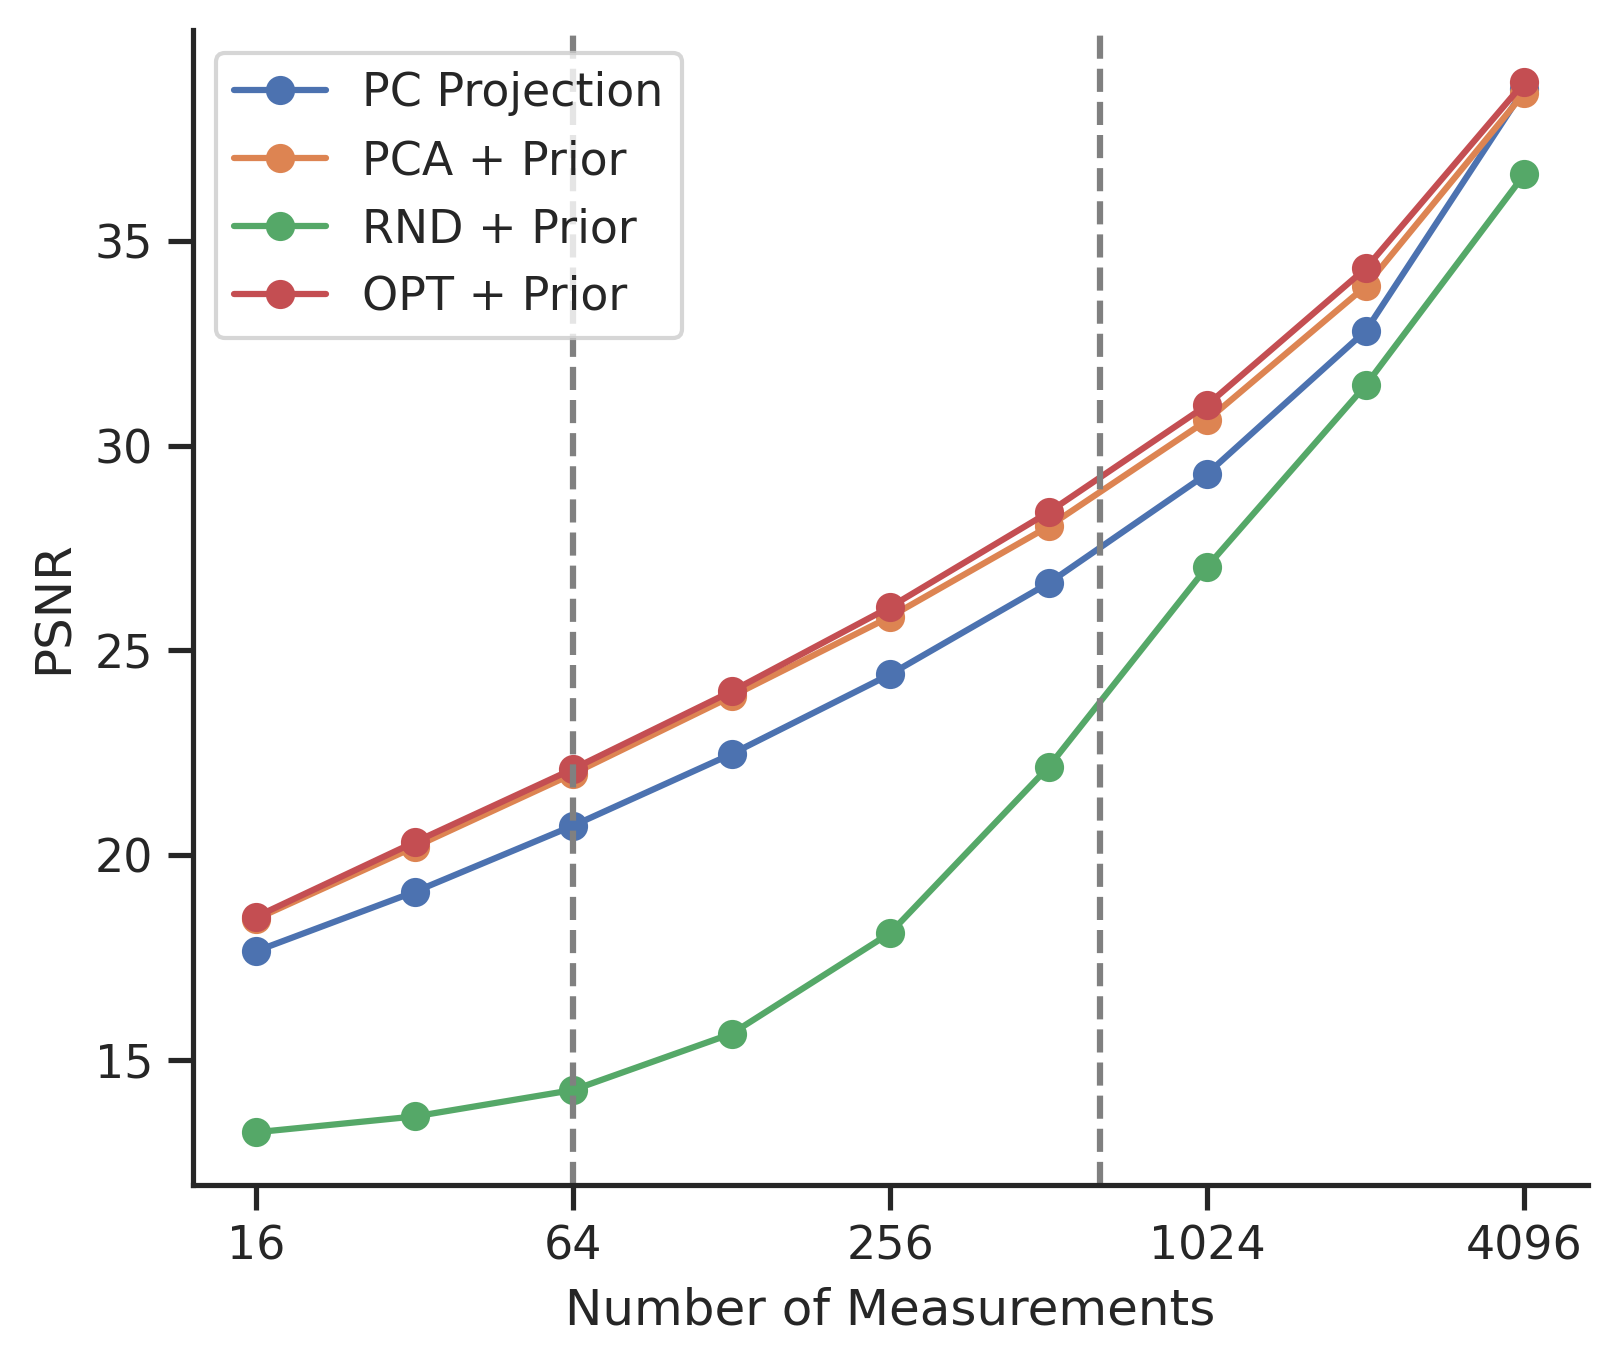

In [47]:
marker = [0.01, 0.1]

fig = plt.figure(figsize=(6, 5))

n_curve = 4
for idx in range(n_curve):
    plt.plot(samples, error[idx][1], '-o')
    
for mrk in marker:
    plt.axvline(mrk * n_pixel, linestyle ="--", color ='gray')

plt.xscale('log', base=2)
plt.xticks(2 ** np.array([4, 6, 8, 10, 12]),
          2 ** np.array([4, 6, 8, 10, 12]))
plt.yticks([15, 20, 25, 30, 35])

plt.xlabel('Number of Measurements')
plt.ylabel('PSNR')
plt.legend(['PC Projection', 'PCA + Prior', 
           'RND + Prior', 'OPT + Prior'])

if save_figure:
    fig_name = 'psnr_celeba'
    fig.savefig('./%s.pdf' % fig_name, bbox_inches='tight')

plt.show()

Delta PSNR [0.05356842 0.11652702 0.11795848 0.12437988 0.23865018 0.34684153
 0.3722463  0.43606256 0.25839637]


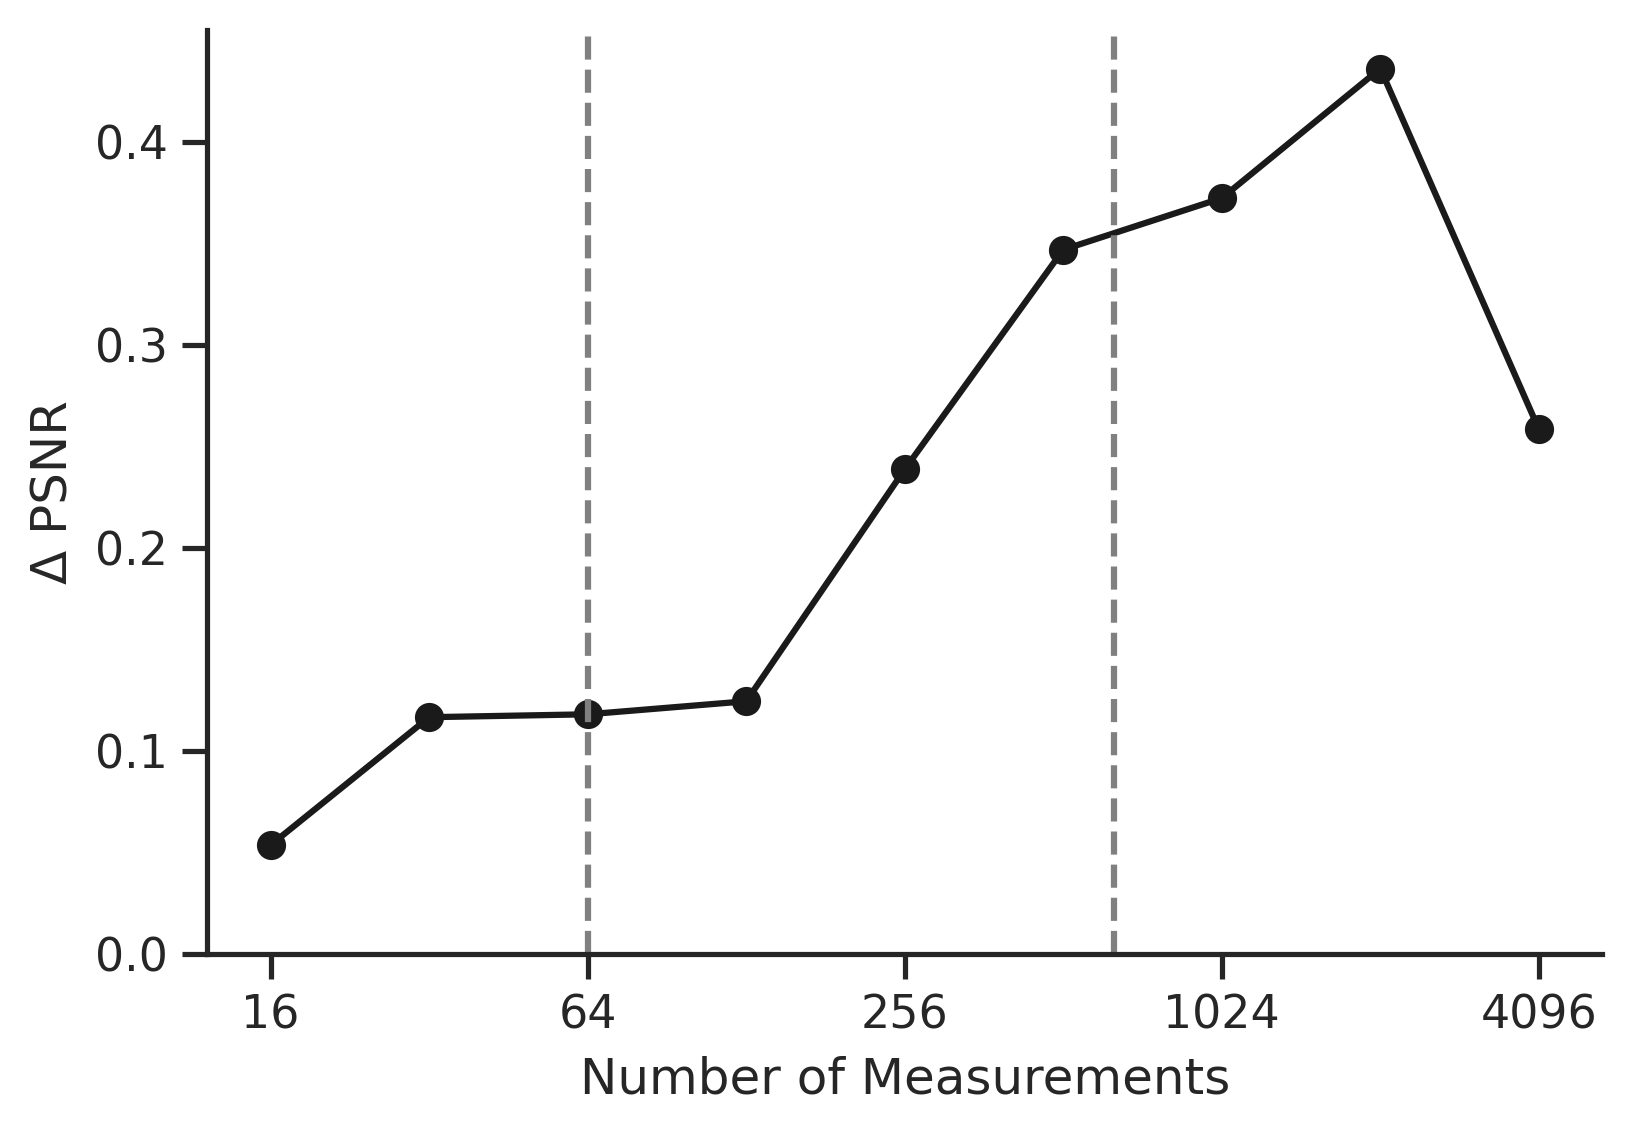

In [48]:
fig = plt.figure(figsize=(6, 4))

plt.plot(samples, error[3][1] - error[1][1],  '-ok')
print('Delta PSNR', error[3][1] - error[1][1])

for mrk in marker:
    plt.axvline(mrk * n_pixel, linestyle ="--", color ='gray')

plt.xscale('log', base=2)
plt.xticks(2 ** np.array([4, 6, 8, 10, 12]),
          2 ** np.array([4, 6, 8, 10, 12]))
plt.yticks([0, 0.1, 0.2, 0.3, 0.4])

plt.xlabel('Number of Measurements')
plt.ylabel('Δ PSNR')

if save_figure:
    fig_name = 'delta_psnr_celeba'
    fig.savefig('./%s.pdf' % fig_name, bbox_inches='tight')
    
plt.show()

### Analysis Reconstructions

In [9]:
n_sample = 512

In [10]:
# PCA 

Q = torch.from_numpy(pca.components_[:n_sample, :]).to(device)
image_vec = test_torch.transpose(2, 3).flatten(1)
recon_vec = image_vec @ Q.t() @ Q
recon_shape = [-1, im_size[0], im_size[2], im_size[1]]
recon_torch = recon_vec.reshape(recon_shape).transpose(2, 3)

recon_pca = recon_torch.detach().permute([0, 2, 3, 1]).cpu().numpy()
print(torch.sum((image_vec - recon_vec) ** 2) / image_vec.shape[0])

tensor(13.8509, device='cuda:0')


In [11]:
# PCA + Prior
loss = torch.nn.MSELoss(reduction='sum')

solver = LinearInverse(n_sample, im_size, model, avg_im).to(device)
solver.beta = 0.10
solver.h_init = 0.10
solver.run_avg = True 
solver.num_avg = 8

solver.assign(torch.from_numpy(pca.components_[:n_sample, :]).to(device))
solver_gpu = torch.nn.DataParallel(solver)
torch.manual_seed(0)

recon = batch_recon(test_torch, solver_gpu,
                   batch_size=32)

recon_dns = recon.detach().cpu().permute([0, 2, 3, 1]).numpy()
print(loss(test_torch, recon) / recon.shape[0])

tensor(10.0692, device='cuda:0')


In [12]:
# OLM + Prior
base_path = './olm_result/CelebA/%d_MSE_celeba.npy'
file_path = base_path % n_sample

order = 5
with open(file_path, 'rb') as fl:
    for count in range(order):
        opt_mtx = np.load(fl)
        
opt_mtx = torch.from_numpy(opt_mtx).to(device)

solver.assign(opt_mtx)
solver_gpu = torch.nn.DataParallel(solver)
torch.manual_seed(0)

recon = batch_recon(test_torch, solver_gpu, batch_size=32)

recon_opt = recon.detach().cpu().permute([0, 2, 3, 1]).numpy()
print(loss(test_torch, recon) / recon.shape[0])

tensor(9.2963, device='cuda:0')


Scatter Plot

In [13]:
psnr_dns = np.array([psnr(test_numpy[idx], recon_dns[idx]) 
            for idx in range(test_numpy.shape[0])])

psnr_opt = np.array([psnr(test_numpy[idx], recon_opt[idx]) 
            for idx in range(test_numpy.shape[0])])

ssim_pca = SSIM(torch.from_numpy(recon_dns).permute([0, 3, 1, 2]).to(device), test_torch).cpu().numpy()
ssim_opt = SSIM(torch.from_numpy(recon_opt).permute([0, 3, 1, 2]).to(device), test_torch).cpu().numpy()

In [14]:
# select a few images to show as example
metric = 'mse'

if metric == 'mse':
    psnr_index = np.argsort(psnr_opt - psnr_dns)
    index_best = psnr_index[-10:][::-1]
    index_select = np.concatenate([index_best])

# select a few images to show as example
if metric == 'ssim':
    ssim_index = np.argsort(ssim_opt - ssim_pca)
    index_best = ssim_index[-10:][::-1]
    index_select = np.concatenate([index_best])

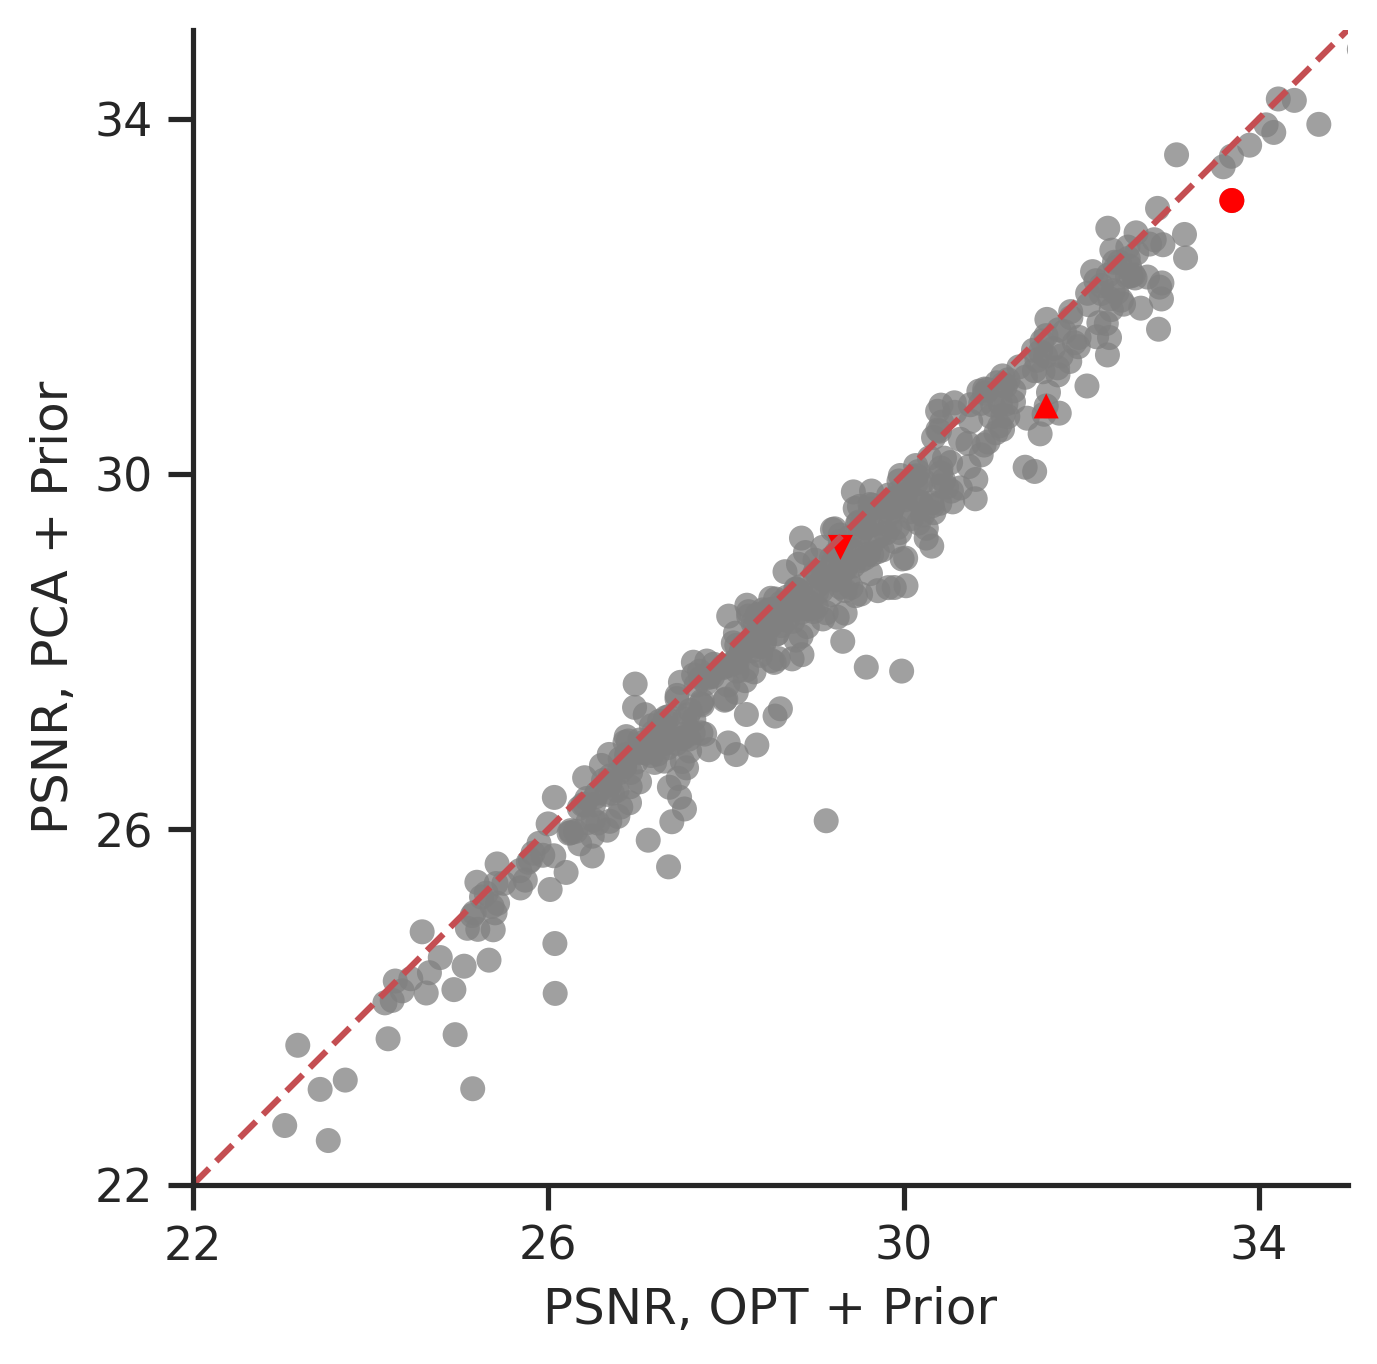

In [20]:
fig = plt.figure(figsize=(5, 5))
plt.scatter(psnr_opt, 
            psnr_dns, 
            c='gray', alpha=0.75,
           edgecolors='none')

select_idx = [251, 437, 30]
markers = ["o", "v", "^"]
for count, idx in enumerate(select_idx):
    plt.scatter(psnr_opt[idx], 
                psnr_dns[idx], 
                c='red', alpha=1.0,
                edgecolors='none',
                marker=markers[count])
    
lb = 22
ub = 35
plt.plot([lb, ub], [lb, ub], '--r')

plt.xlabel('PSNR, OPT + Prior')
plt.ylabel('PSNR, PCA + Prior')

plt.axis('square')

plt.xlim([lb, ub])
plt.ylim([lb, ub])
plt.xticks(range(lb, ub + 1, 4))
plt.yticks(range(lb, ub + 1, 4))

if save_figure:
    fig_name = 'scatter_celeba'
    fig.savefig('./%s.pdf' % fig_name, bbox_inches='tight')

plt.show()

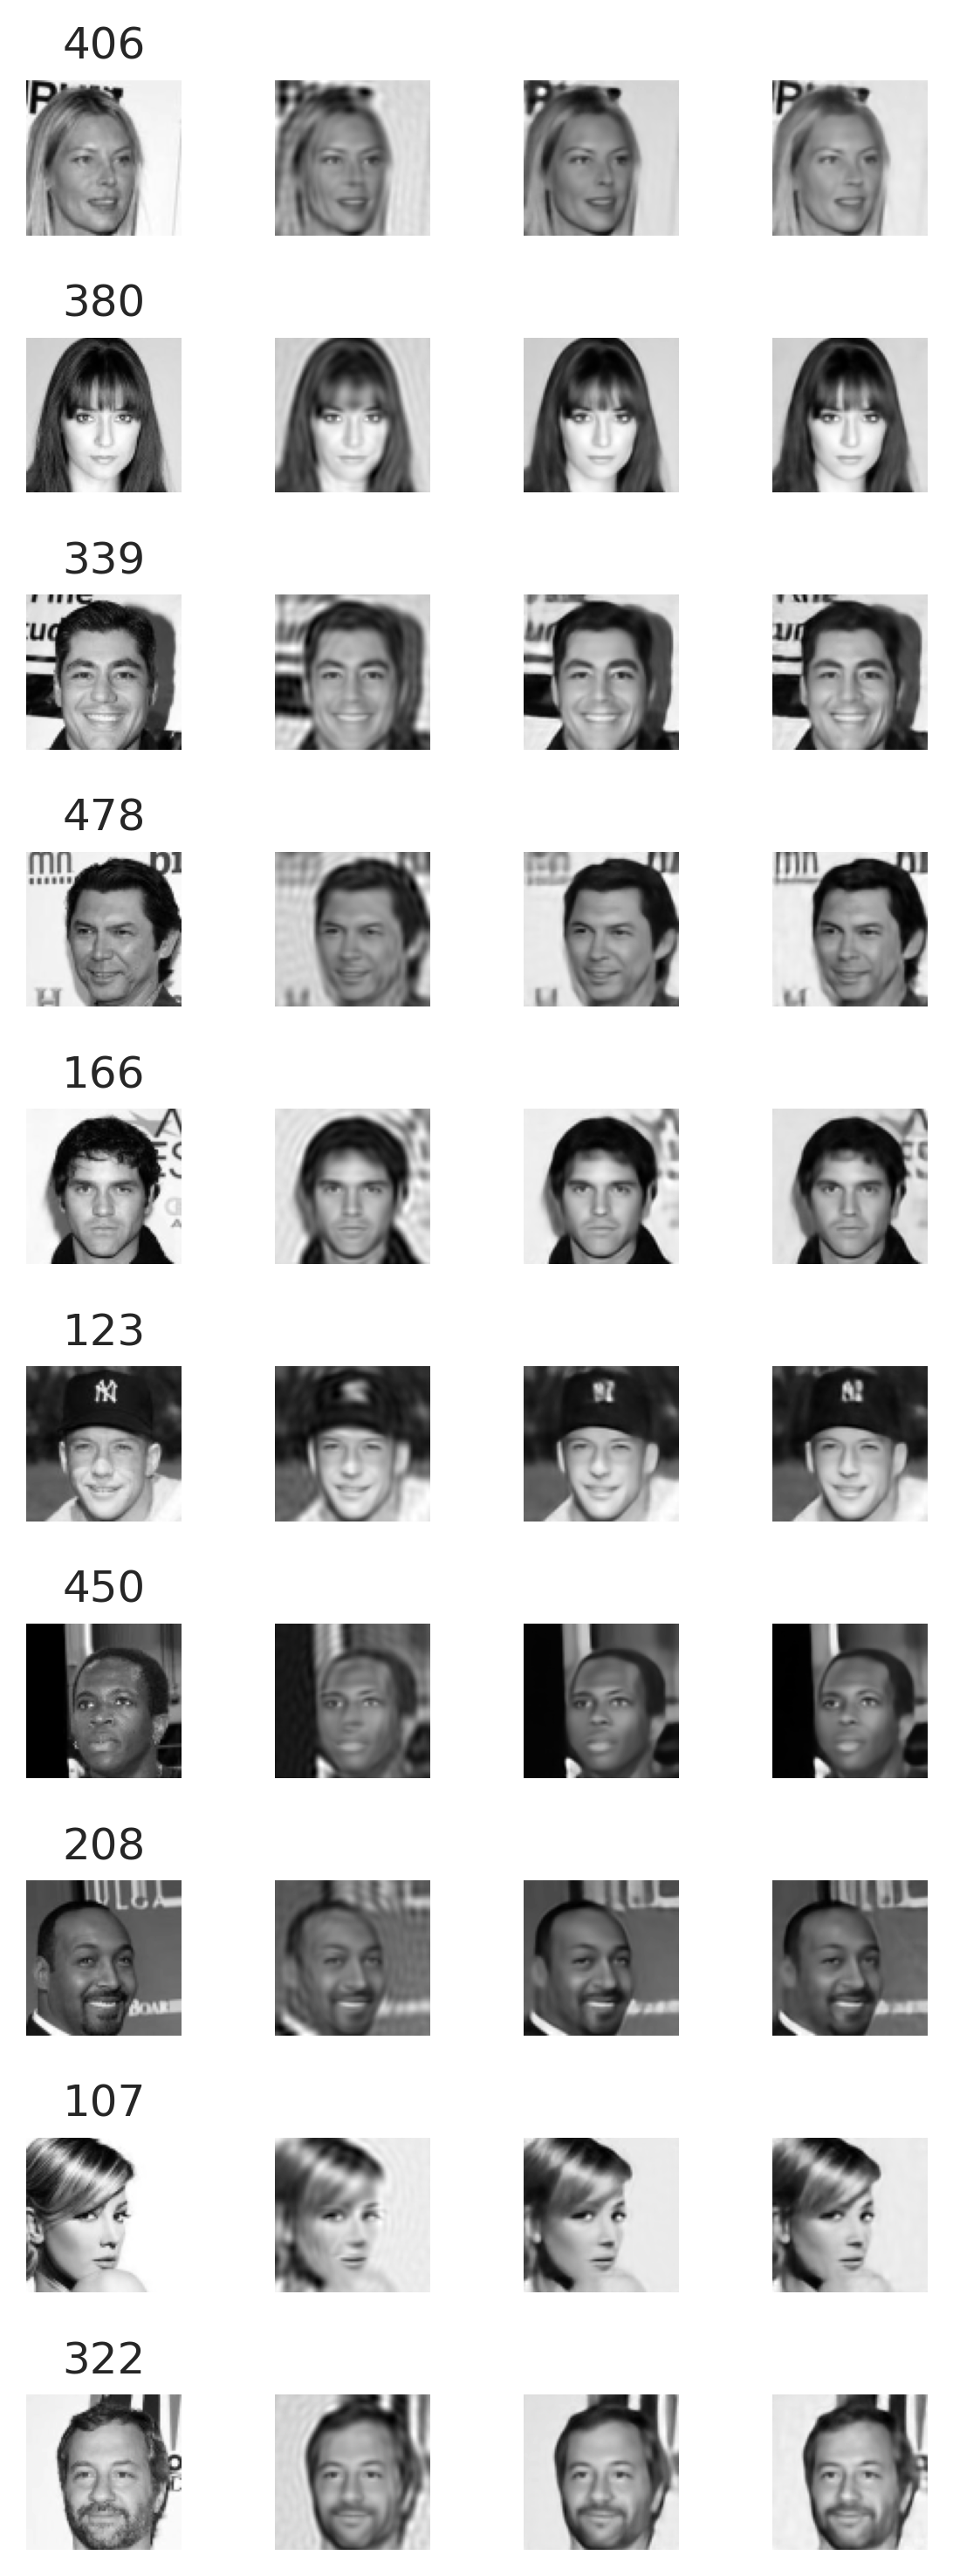

In [16]:
n_test = test_set.shape[0]
img_idx = index_select

n_row = len(img_idx)
n_col = 4
fig, axs = plt.subplots(n_row, n_col, figsize=(n_col, n_row))

all_recon = [test_numpy, recon_pca, recon_dns, recon_opt]
for idx in range(n_row):
    image_id = img_idx[idx]
    for idy in range(n_col):
        image = all_recon[idy][image_id]
        axs[idx, idy].imshow(image, cmap='gray')        
    axs[idx, 0].set_title(image_id)
    
for ax in axs.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()